In [7]:
import tensorflow as tf
from tensorflow import keras
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

%matplotlib inline

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [4]:
dataset=pd.read_csv('/content/heart.xls')

In [5]:
dataset.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


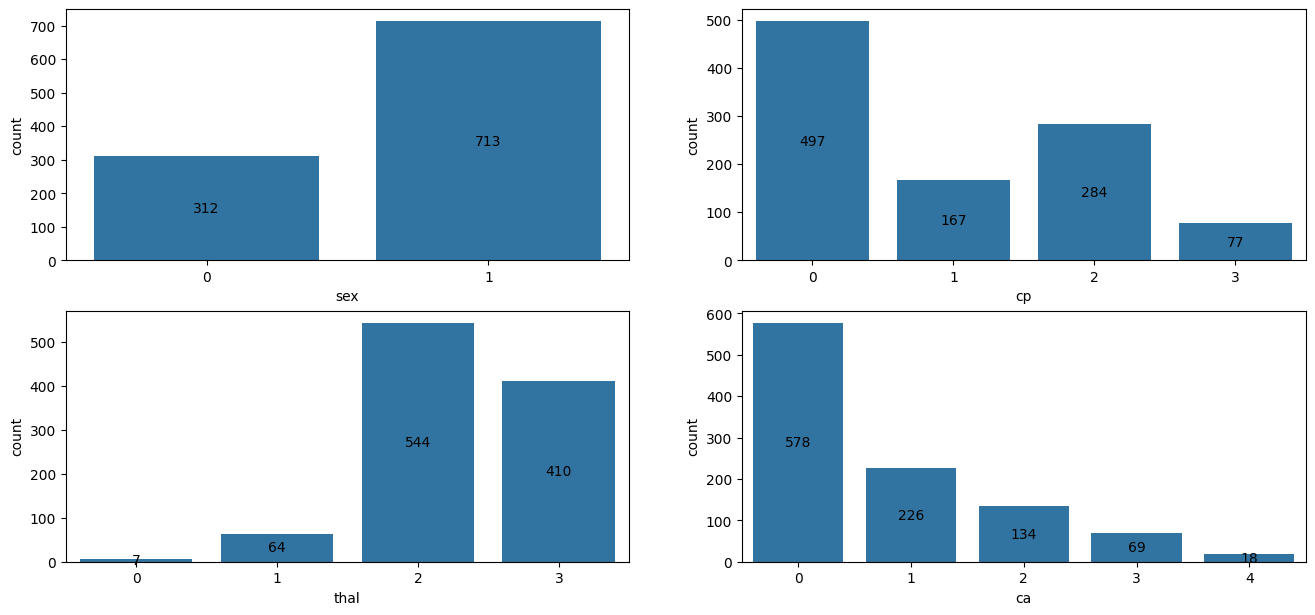

In [8]:
cols=["sex","cp","thal","ca"]

fig=plt.figure(figsize=(16,15))

for idx,col in enumerate(cols):
  ax=plt.subplot(4,2,idx+1)
  sns.countplot(x=dataset[col],ax=ax)
  for container in ax.containers:
    ax.bar_label(container,label_type="center")

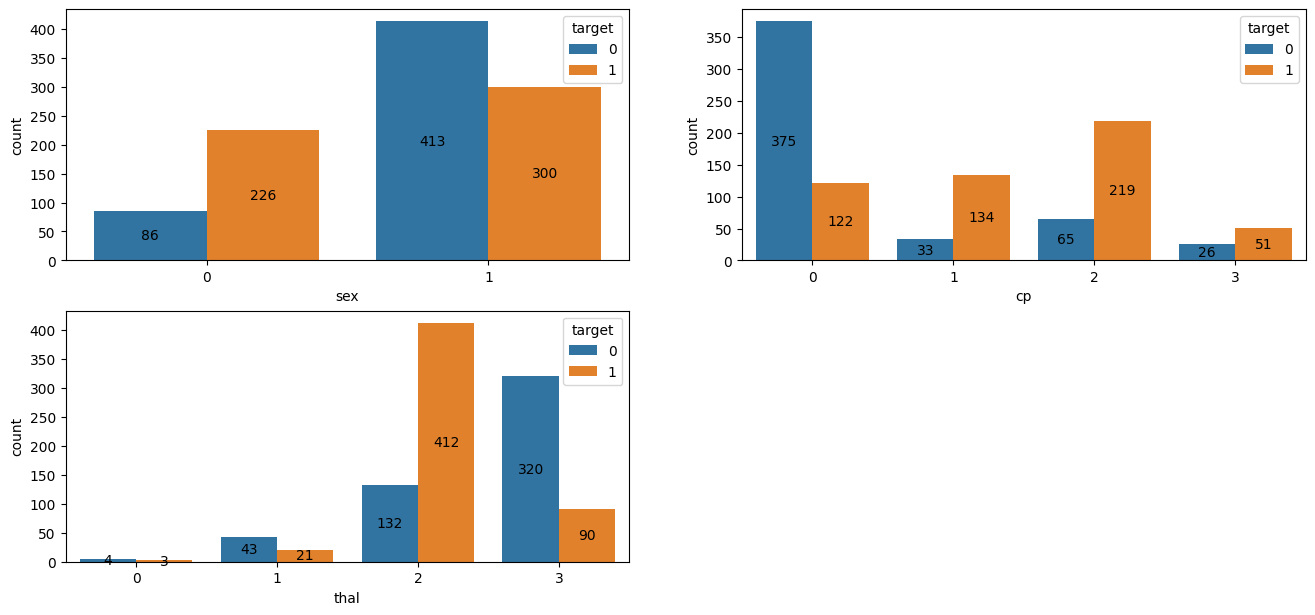

In [9]:
fig=plt.figure(figsize=(16,15))

for idx,col in enumerate(cols[:-1]):
  ax=plt.subplot(4,2,idx+1)
  sns.countplot(x=dataset[col],ax=ax,hue=dataset['target'])
  for container in ax.containers:
    ax.bar_label(container,label_type="center")

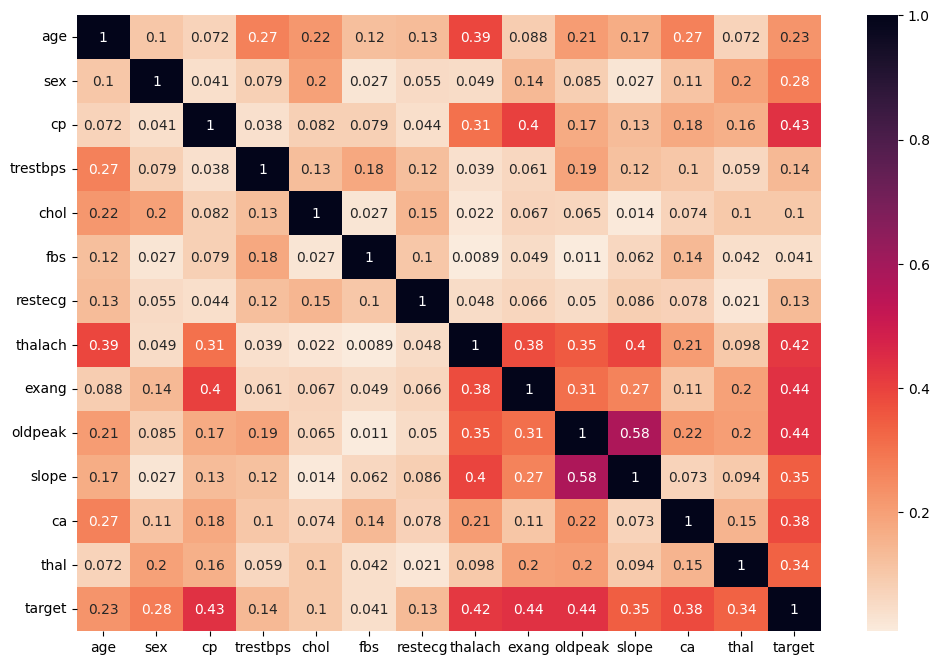

In [10]:
correlations=abs(dataset.corr())
plt.figure(figsize=(12,8))
sns.heatmap(correlations,annot=True,cmap="rocket_r")
plt.show()

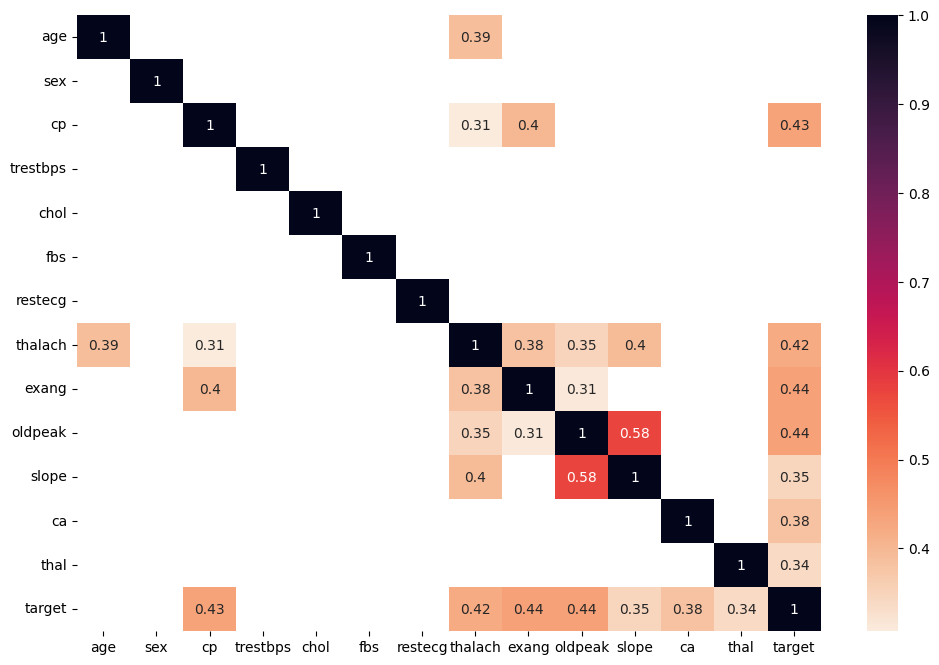

In [11]:
plt.figure(figsize=(12,8))
sns.heatmap(correlations[correlations>0.30],annot=True,cmap="rocket_r")
plt.show()

In [12]:
X=dataset.drop(["target"],axis=1)
Y=dataset["target"]

In [13]:
X_train,X_val,y_train,y_val=train_test_split(X,Y,test_size=0.10,random_state=417)

In [34]:
input_dim = X_train.shape[1]
model = tf.keras.Sequential([
        # Входной слой
        Dense(64, activation='relu', input_shape=(input_dim,)),
        BatchNormalization(),
        Dropout(0.3),

        # Скрытые слои
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),

        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),

        Dense(32, activation='relu'),
        Dropout(0.2),

        # Выходной слой (бинарная классификация)
        Dense(1, activation='sigmoid')
    ])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [35]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', 'precision', 'recall', 'auc']
)

In [36]:
# Callbacks для улучшения обучения
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-7,
    verbose=1
)

# Обучение модели
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=120,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/120
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.5539 - auc: 0.5869 - loss: 0.8870 - precision: 0.5468 - recall: 0.9063 - val_accuracy: 0.6893 - val_auc: 0.7314 - val_loss: 0.6110 - val_precision: 0.6970 - val_recall: 0.7931 - learning_rate: 0.0010
Epoch 2/120
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5975 - auc: 0.6767 - loss: 0.7184 - precision: 0.5637 - recall: 0.7776 - val_accuracy: 0.6311 - val_auc: 0.7278 - val_loss: 0.6712 - val_precision: 0.8125 - val_recall: 0.4483 - learning_rate: 0.0010
Epoch 3/120
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6515 - auc: 0.7062 - loss: 0.6634 - precision: 0.6482 - recall: 0.7095 - val_accuracy: 0.6311 - val_auc: 0.7356 - val_loss: 0.6507 - val_precision: 0.8125 - val_recall: 0.4483 - learning_rate: 0.0010
Epoch 4/120
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6399 - auc: 0.6868 - loss: 0.6716 - precision: 0.6304 - recall: 0.6817 - val_accuracy: 0.6990 - val_auc: 0.7506 - val_loss: 0.5946 - val_pr

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.80      0.81        45
           1       0.85      0.86      0.85        58

    accuracy                           0.83       103
   macro avg       0.83      0.83      0.83       103
weighted avg       0.83      0.83      0.83       103

Confusion Matrix:
[[36  9]
 [ 8 50]]


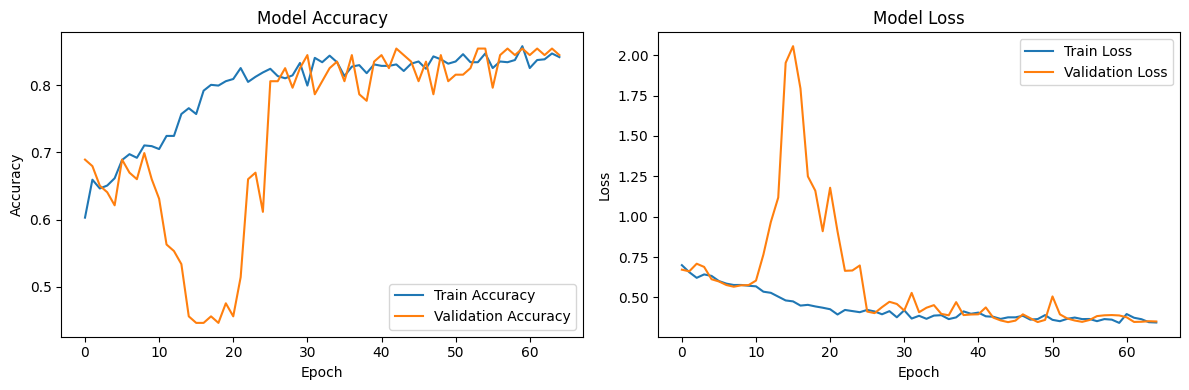

In [28]:
from sklearn.metrics import classification_report, confusion_matrix
# Предсказания
y_pred_proba = model.predict(X_val)
y_pred = (y_pred_proba > 0.5).astype(int)

# Метрики
print("Classification Report:")
print(classification_report(y_val, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred))

# Графики обучения
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Accuracy
    ax1.plot(history.history['accuracy'], label='Train Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax1.set_title('Model Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()

    # Loss
    ax2.plot(history.history['loss'], label='Train Loss')
    ax2.plot(history.history['val_loss'], label='Validation Loss')
    ax2.set_title('Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()

    plt.tight_layout()
    plt.show()

plot_training_history(history)